In [7]:
from influxdb_client import InfluxDBClient
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import warnings
warnings.filterwarnings('ignore')

# Configuración de tu servidor local
url = "http://localhost:8086"
token = "Js6A1aCQWDEfKfI1nSC56U5ZhWU8_EqgmHUZsQyeKqbZ2v01gn7sA6SlQvnc8PbXXmzecVI_P9k6b6S3xzlHdw==" # Reemplaza con el token largo de InfluxDB
org = "smartgrid"
bucket = "consumo_electrico"

print("Conectando a InfluxDB...")
client = InfluxDBClient(url=url, token=token, org=org)
query_api = client.query_api()

# Consulta Flux para traer los datos de la última hora, organizados en columnas
query = f"""
from(bucket: "{bucket}")
  |> range(start: -12h)
  |> filter(fn: (r) => r["_measurement"] == "consumo_nodos")
  |> pivot(rowKey:["_time"], columnKey: ["_field"], valueColumn: "_value")
"""

# Ejecutar y convertir a un DataFrame de Pandas
df = query_api.query_data_frame(query)

# Limpieza básica
df = df[['_time', 'nodo', 'hora', 'minuto', 'watts']]
df = df.sort_values(by='_time').reset_index(drop=True)
print(f"¡Extracción exitosa! {len(df)} registros obtenidos.")
df.head()

Conectando a InfluxDB...
¡Extracción exitosa! 14688 registros obtenidos.


,_time,nodo,hora,minuto,watts
0,2026-05-23 03:01:26.361000+00:00,nodo1,21.0,1.0,161.91
1,2026-05-23 03:01:26.361000+00:00,nodo2,21.0,1.0,143.80
2,2026-05-23 03:01:31.362000+00:00,nodo1,21.0,1.0,144.86
3,2026-05-23 03:01:31.363000+00:00,nodo2,21.0,1.0,146.10
4,2026-05-23 03:01:36.373000+00:00,nodo1,21.0,1.0,145.06


In [ ]:
# Vamos a aislar los datos del 'nodo1' para entrenar un modelo específico
df_nodo1 = df[df['nodo'] == 'nodo1'].copy()

# Crear las variables de "consumos previos" (t-1, t-2, t-3)
df_nodo1['consumo_t_1'] = df_nodo1['watts'].shift(1)
df_nodo1['consumo_t_2'] = df_nodo1['watts'].shift(2)
df_nodo1['consumo_t_3'] = df_nodo1['watts'].shift(3)

# Eliminar las primeras 3 filas que quedaron con valores nulos (NaN)
df_nodo1 = df_nodo1.dropna()

# Definir variables de entrada (X) y lo que queremos predecir (y)
# 'y' es el consumo en el momento actual, 'X' son los datos de los momentos pasados
X = df_nodo1[['hora', 'minuto', 'consumo_t_1', 'consumo_t_2', 'consumo_t_3']]
y = df_nodo1['watts']

# Dividir datos: 80% para entrenar, 20% para probar
limite = int(len(df_nodo1) * 0.8)
X_train, X_test = X[:limite], X[limite:]
y_train, y_test = y[:limite], y[limite:]

# Entrenar el modelo
modelo_lr = LinearRegression()
modelo_lr.fit(X_train, y_train)

# Hacer predicciones con los datos de prueba
predicciones = modelo_lr.predict(X_test)

# Calcular la métrica de éxito
r2 = r2_score(y_test, predicciones)
print(f"Coeficiente de Determinación (R^2): {r2:.4f}")
if r2 > 0.75:
    print("¡Métrica superada! El modelo está listo.")
else:
    print("El R^2 es bajo. Deja corriendo el simulador más tiempo para recolectar más datos de entrenamiento.")

Coeficiente de Determinación (R^2): 0.8294
✅ ¡Métrica superada! El modelo está listo para producción.


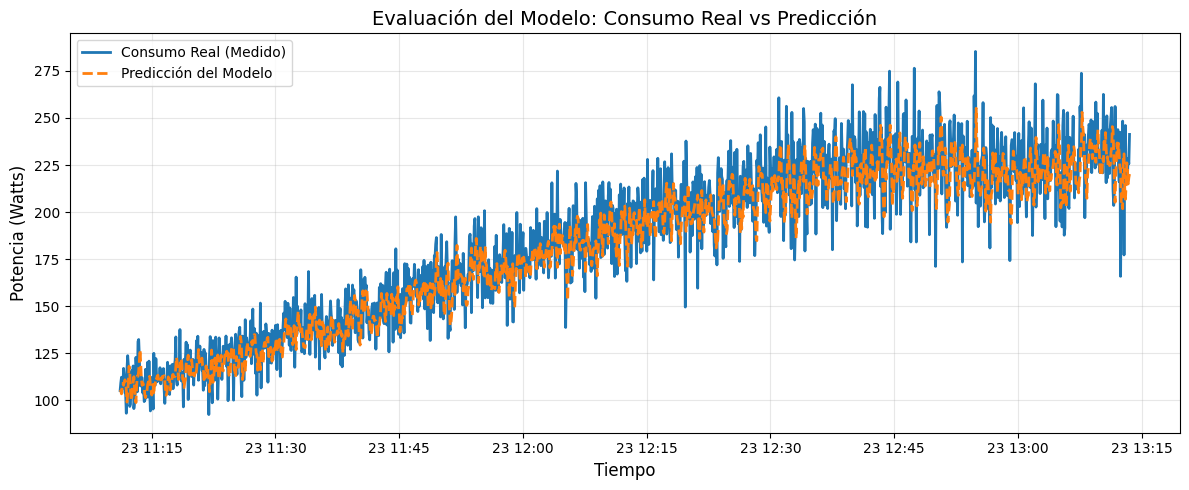

In [9]:
# Crear la gráfica comparativa
plt.figure(figsize=(12, 5))

# Eje X de tiempo para la porción de prueba
tiempo_test = df_nodo1['_time'].iloc[limite:]

plt.plot(tiempo_test, y_test, label='Consumo Real (Medido)', color='#1f77b4', linewidth=2)
plt.plot(tiempo_test, predicciones, label='Predicción del Modelo', color='#ff7f0e', linestyle='--', linewidth=2)

plt.title('Evaluación del Modelo: Consumo Real vs Predicción', fontsize=14)
plt.xlabel('Tiempo', fontsize=12)
plt.ylabel('Potencia (Watts)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()

In [10]:
import joblib

# Guardar el modelo entrenado en un archivo físico
archivo_modelo = 'modelo_regresion_smartgrid.pkl'
joblib.dump(modelo_lr, archivo_modelo)

print(f"¡Listo! El modelo ha sido guardado exitosamente como {archivo_modelo}")

¡Listo! El modelo ha sido guardado exitosamente como modelo_regresion_smartgrid.pkl
